Comparison of all scenarios and simulations across the entire model domain and all biological functional groups.

In [1]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

In [3]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/heatmap_data.csv")

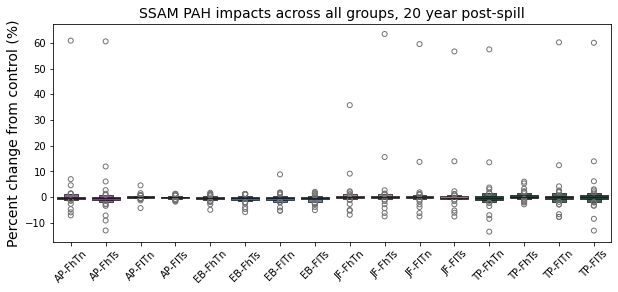

In [51]:
plt.figure(figsize=(10, 4))

custom_palette = sns.color_palette([
'#863092', '#863092','#863092','#863092',
'#2F61A4', '#2F61A4','#2F61A4','#2F61A4',
"#A27170", "#A27170","#A27170","#A27170",
"#154734","#154734","#154734","#154734"])
ax = sns.boxenplot(df,palette=custom_palette) 
plt.ylabel('Percent change from control (%)', fontsize = 14)
plt.title('SSAM PAH impacts across all groups, 20 year post-spill', fontsize = 14)
plt.xticks(rotation=45); #

In [5]:
ag = pd.read_csv("/ocean/rlovindeer/MOAD/Lovindeeretal-MPRI1paper/averaged_data.csv")

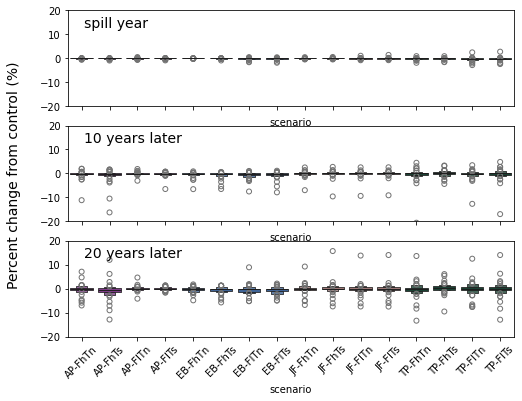

In [54]:
time_labels = ['spill year', '10 years later', '20 years later']
fig, axs = plt.subplots(3, 1, figsize=(8, 6)) 
for time, ax, mode in zip(time_labels,axs, range(3)):
    df_pivot = ag.loc[ag['time_label'] == time].pivot_table(
        index='bio_group', 
        columns='scenario', 
        values='percent_change', 
    )                
    ax.set_ylim(-20, 20)
    sns.boxenplot(df_pivot,palette=custom_palette,ax=ax)
    ax.text(0.1, 13, time, fontsize = 14)
    if mode < 2: ax.xaxis.set_ticklabels('')
fig.supylabel('Percent change from control (%)', fontsize = 14)
plt.xticks(rotation=45)
fig.savefig('Figures/Boxen_all.jpg', dpi=300) 

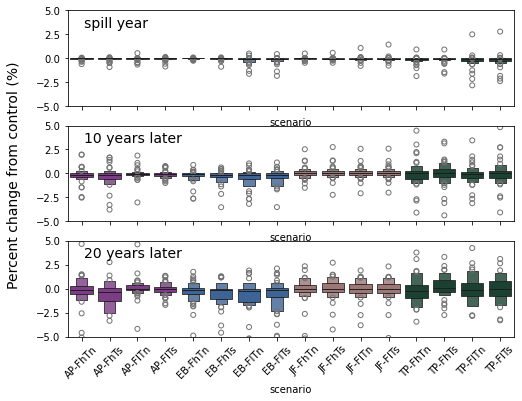

In [56]:
time_labels = ['spill year', '10 years later', '20 years later']
fig, axs = plt.subplots(3, 1, figsize=(8, 6))
for time, ax, mode in zip(time_labels,axs, range(3)):
    df_pivot = ag.loc[ag['time_label'] == time].pivot_table(
        index='bio_group', 
        columns='scenario', 
        values='percent_change', 
    )
    ax.set_ylim(-5, 5)         
    sns.boxenplot(df_pivot,palette=custom_palette,ax=ax)
    ax.text(0.1, 3.25, time, fontsize = 14)
    if mode < 2: ax.xaxis.set_ticklabels('')
fig.supylabel('Percent change from control (%)', fontsize = 14)
plt.xticks(rotation=45)
fig.savefig('Figures/Boxen_zoomed.jpg', dpi=300) 